In [1]:
# 1. Import Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

2026-03-25 05:04:40.722837: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774415080.909384      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774415080.963957      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774415081.451859      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774415081.451902      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774415081.451908      55 computation_placer.cc:177] computation placer alr

In [2]:
# 2. Set Dataset Path
train_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_train"
test_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_test"
validation_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_validate"

In [3]:
# 3. Data Preprocessing (Train + Validation Split)

train_datagen = ImageDataGenerator(
rescale=1./255,
rotation_range=40,
width_shift_range=0.2,
height_shift_range=0.2,
shear_range=0.2,
zoom_range=0.2,
horizontal_flip=True,)

#Resize all images to 150x150
train_generator = train_datagen.flow_from_directory(
    train_dir,target_size=(150, 150),batch_size=32, class_mode='categorical')

#Validation Data Set should not be augmented
test_datagen = ImageDataGenerator(rescale=1./255)

#Resize all images to 150x150
validation_generator = test_datagen.flow_from_directory(
    validation_dir,target_size=(150, 150),batch_size=32, class_mode='categorical')

Found 11229 images belonging to 6 classes.
Found 2805 images belonging to 6 classes.


In [4]:
#4. Load Test Data
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 3000 images belonging to 6 classes.


In [5]:
#5. Build CNN Model

model = models.Sequential()

# Block 1
# Conv2D(32, (3,3)) + MaxPooling

# Extracts low-level features
# Learns:
#       edges
#       corners
#       textures

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(layers.MaxPooling2D(2,2))
# Block 2
# Conv2D(64, (3,3)) + MaxPooling
# Extracts mid-level features
# Learns:
#       shapes
#       patterns
#       object parts
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Block 3
# Conv2D(128, (3,3)) + MaxPooling
# Extracts high-level features
#Learns:
#     full objects
#     class-specific patterns
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

#Extra Code
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Flatten
# Flatten()
# Converts 2D feature maps → 1D vector
# Required before Dense layer
model.add(layers.Flatten())

# Dense Layers (Dense + Dropout)
# Dense(128, relu)
# Dropout(0.5)
# Fully connected layer → learns classification logic
# Dropout:
# Prevents overfitting
# Randomly drops 50% neurons during training
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))

# Output Layer (6 classes)
# Dense(6, softmax)
# 6 neurons → 6 classes
# Softmax → probability distribution

model.add(layers.Dense(6, activation='softmax'))

# What you just built?
# CNN with 3 convolution layers ReLU activation MaxPooling Dropout (prevents overfitting) 
# Softmax output (6 classes)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1774415626.666496      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774415626.672684      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [6]:
#6. Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
# 7. Train Model
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1774415646.364814     151 service.cc:152] XLA service 0x78203000c480 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774415646.364868     151 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774415646.364875     151 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774415646.846593     151 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/351 ━━━━━━━━━━━━━━━━━━━━ 42:26 7s/step - accuracy: 0.1875 - loss: 1.8027

I0000 00:00:1774415651.498220     151 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


351/351 ━━━━━━━━━━━━━━━━━━━━ 124s 333ms/step - accuracy: 0.4023 - loss: 1.4548 - val_accuracy: 0.5661 - val_loss: 1.1225
Epoch 2/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 77s 220ms/step - accuracy: 0.5277 - loss: 1.1781 - val_accuracy: 0.5993 - val_loss: 1.0595
Epoch 3/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 76s 217ms/step - accuracy: 0.5729 - loss: 1.1065 - val_accuracy: 0.7012 - val_loss: 0.8163
Epoch 4/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 76s 218ms/step - accuracy: 0.6068 - loss: 1.0145 - val_accuracy: 0.7137 - val_loss: 0.7494
Epoch 5/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 76s 217ms/step - accuracy: 0.6430 - loss: 0.9620 - val_accuracy: 0.7811 - val_loss: 0.6755
Epoch 6/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 75s 213ms/step - accuracy: 0.6753 - loss: 0.8834 - val_accuracy: 0.7636 - val_loss: 0.6622
Epoch 7/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 73s 207ms/step - accuracy: 0.6955 - loss: 0.8401 - val_accuracy: 0.7597 - val_loss: 0.6838
Epoch 8/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 73s 208ms/step - accuracy: 0.7205 - loss: 0.7834 - va

In [8]:
# 8. Evaluate on Test Data
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 191ms/step - accuracy: 0.8582 - loss: 0.4046
Test Accuracy: 0.8569999933242798


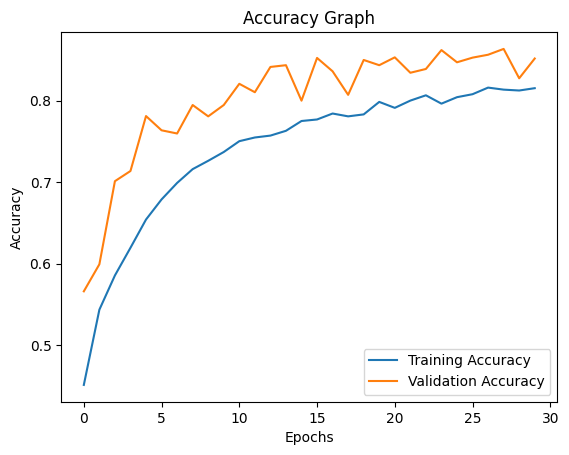

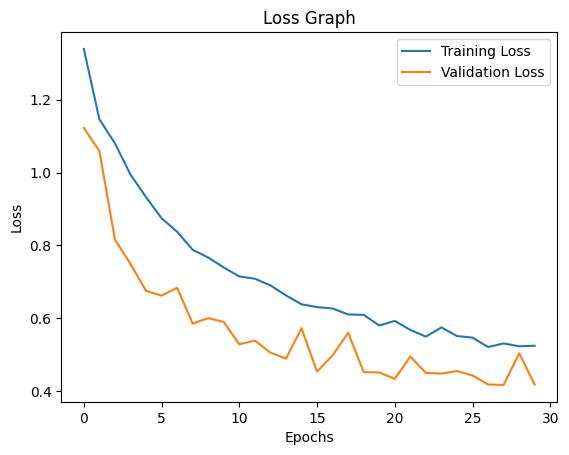

In [9]:
# 9. Accuracy & Loss Graphs
# Accuracy Plot
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# Loss Plot
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

**Final Understanding : Pipeline you implemented:**

**Dataset → Train Split → CNN → Validation → Test → Graphs**